In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

# Challenge 1 - clean the data

Import the data in ../data/economies_of_scale.csv into a pandas dataframe

In [5]:
#your code here

profit = pd.read_csv('../data/economies_of_scale.csv')
print('Shape:', profit.shape)
print('Data types:')
print(profit.dtypes)
print()
profit.head()

Shape: (95, 2)
Data types:
items_produced     int64
total_profit      object
dtype: object



,items_produced,total_profit
0,899,111K$
1,2051,5953K$
2,1613,822K$
3,1347,-1269K$
4,462,313K$


Notice the column *total_profit* is in text. You first need to clean this data to turn it back into numeric data. You can consider using the method *apply* or *replace* to do this

In [6]:
# clean the column total_profit to make it nume

profit['total_profit'] = profit['total_profit'].str.replace('K$', '', regex=False).astype(float) * 1000

print('Cleaned! Data types now:')
print(profit.dtypes)
print()
profit.head()

Cleaned! Data types now:
items_produced      int64
total_profit      float64
dtype: object



,items_produced,total_profit
0,899,111000.0
1,2051,5953000.0
2,1613,822000.0
3,1347,-1269000.0
4,462,313000.0


Now let's visualize how total profitability changes with number of machines sold 

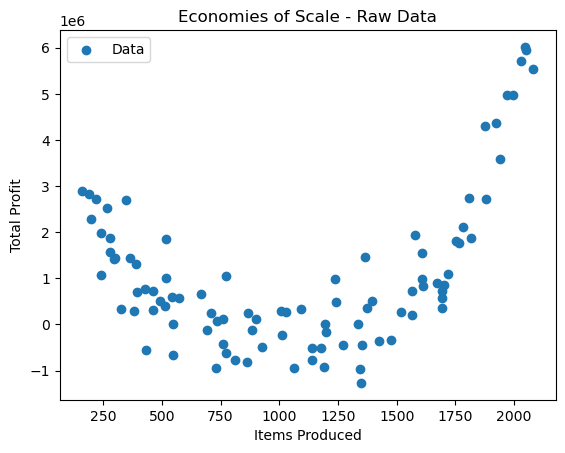

In [7]:
plt.scatter(profit['items_produced'], profit['total_profit'], label="Data")
plt.xlabel('Items Produced')
plt.ylabel('Total Profit')
plt.title('Economies of Scale - Raw Data')
plt.legend()
plt.show()

This is an expected phenomenon called [*economies of scale*](https://en.wikipedia.org/wiki/Economies_of_scale): If you sell a very niche product (few sales) you can usuallyy charge a premium and have good profitability, since there will likely not be sufficient market for many competitors. As your product becomes more mainstream and more players enter the market, the supply pressures lower your profitability. Finally, once you break through to become a large player, as you expand your operations, your fixed costs become more and more diluted by the total number of items sold and your profitability increases again due to your lower operating costs.

In this exercise we are going to try to predict the profitability of the company based on the number of items sold.
Select your Features (X) and your Targets (y) and perform a test-train split.

In [8]:
from sklearn.model_selection import train_test_split
X = profit[['items_produced']]   # 2D input (double brackets = DataFrame, not Series)
y = profit['total_profit']        # 1D target (single bracket = Series)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}  →  {len(X_train)} rows for training')
print(f'X_test shape:  {X_test.shape}   →  {len(X_test)} rows for testing')


X_train shape: (76, 1)  →  76 rows for training
X_test shape:  (19, 1)   →  19 rows for testing


# Degree 1

Let's first approach this problem with a simple linear regression

Degree 1 — Train MSE: 2,413,863,712,741  |  Test MSE: 2,286,152,701,831


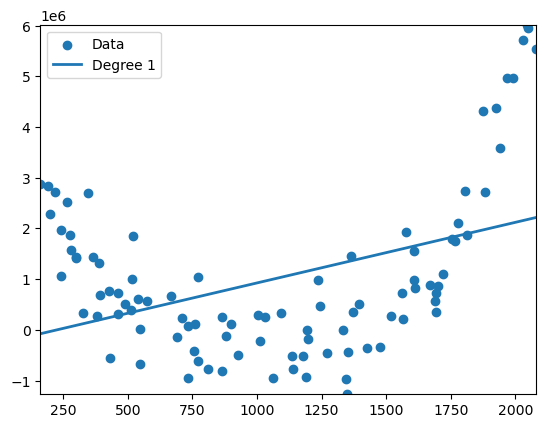

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_poly_train = scaler.fit_transform(X_train)
X_poly_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)
print(f'Degree 1 — Train MSE: {train_error:,.0f}  |  Test MSE: {test_error:,.0f}')


plt.scatter(X, y, label="Data")
X_plot = pd.DataFrame(np.linspace(100, 2200, 100).reshape(-1, 1), columns=['items_produced'])
y_plot = model.predict(scaler.transform(X_plot))
plt.plot(X_plot, y_plot, label="Degree 1", linewidth=2)
plt.xlim(X['items_produced'].min(), X['items_produced'].max())
plt.ylim(y.min(), y.max())
plt.legend()
plt.show()

We can easily see this is not a good model. It completely misses the niche side of the market and it does not approximate well  the profitability of the large players. This is a weak model with little generalization power.
This model exhibits *high bias*: the data DOES NOT fit well with the training data. It is however a nodel with *low variance*: the profit predicted  swings in expected ways with the sold units.
This is typical in cases of *Underfitting*.

# Degree 2

We are going to introdduce a common regression technique called *polynomial regression*. When you have a single feature $X$ and you apply a linear regression you are finding the optimal coefficientf for the formula

$$ y = \beta_0 + \beta_1 X $$

We are going to create new features by considering powers of the base feature $X$, so a *quadratic* regression would produce the optimal coefficients for the formula

$$y = \beta_0 + \beta_1 X + \beta_2 X^2$$

and a *cubic* regression would produce the optimal coefficients for the formula

$$y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3$$

and so on.

This way, with a single feature *X* you can produce multiple features $X^2$, $X^3$, etc to apply a higher dimensional Linear Regression. We create these extra features $X^2$, $X^3$ using a sklearn preprocessing tool called *PolynomialFeatures*

In [14]:
#polynomial features of degree 1 gives us a constant term plus the linear term 
from sklearn.preprocessing import PolynomialFeatures

X_example = [[1],[2],[3],[5]]
poly_features = PolynomialFeatures(degree=1)
poly_features.fit_transform(X_example)

array([[1., 1.],
       [1., 2.],
       [1., 3.],
       [1., 5.]])

In [15]:
#polynomial features of degree 2 gives us a constant term plus the linear term, plus a quadratic term 
X_example = [[1],[2],[3],[5]]
poly_features = PolynomialFeatures(degree=2)
poly_features.fit_transform(X_example)

array([[ 1.,  1.,  1.],
       [ 1.,  2.,  4.],
       [ 1.,  3.,  9.],
       [ 1.,  5., 25.]])

In [19]:
#polynomial features of degree 2 gives us a constant term plus the linear term, plus a cubic term 
X_example = [[1],[2],[3],[5]]
poly_features = PolynomialFeatures(degree=3)
poly_features.fit_transform(X_example)

array([[  1.,   1.,   1.,   1.],
       [  1.,   2.,   4.,   8.],
       [  1.,   3.,   9.,  27.],
       [  1.,   5.,  25., 125.]])

And so on. So, if we want to use a quadratic approximation to this problem we run the following code

Degree 2 — Train MSE: 508,165,153,636  |  Test MSE: 425,200,367,973


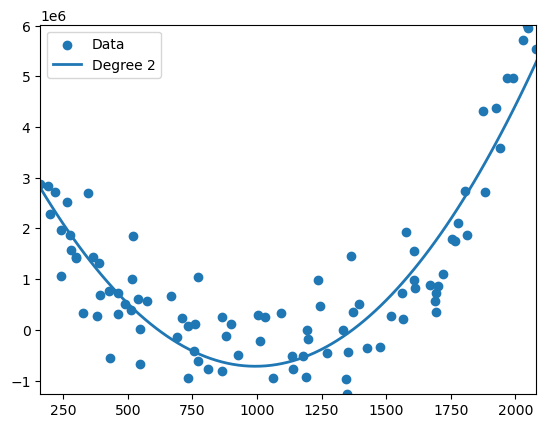

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

scaler = StandardScaler()
poly_features = PolynomialFeatures(degree=2)  # here is where the 2 comes in
X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
X_poly_test = scaler.transform(poly_features.transform(X_test))

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)
print(f'Degree 2 — Train MSE: {train_error:,.0f}  |  Test MSE: {test_error:,.0f}')

plt.scatter(X, y, label="Data")
X_plot = pd.DataFrame(np.linspace(100, 2200, 100).reshape(-1, 1), columns=['items_produced'])
y_plot = model.predict(scaler.transform(poly_features.transform(X_plot)))
plt.plot(X_plot, y_plot, label="Degree 2", linewidth=2)
plt.xlim(X['items_produced'].min(), X['items_produced'].max())
plt.ylim(y.min(), y.max())
plt.legend()
plt.show()

You can see the fit obviously looks much better just by visual inspection. Let's keep it going...

# Challenge 2 -Degree 4

Replicate the exercise above but now for degree 4. Is the fit improving?

In [22]:
#Al subir a grado 4, le has dado al modelo 5 variables ($1, X, X^2, X^3, X^4$) en lugar de 2. 
#Cuantas más variables y potencias tiene un modelo, matemáticamente tiene más Varianza 
#porque es más sensible a los datos.

Degree 4 — Train MSE: 382,344,074,348  |  Test MSE: 281,263,489,074


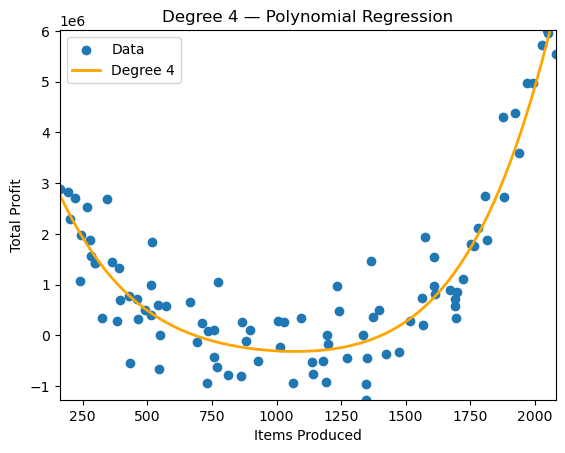

In [21]:
#your code here
scaler = StandardScaler()
poly_features = PolynomialFeatures(degree=4)   # ← only change: 4 instead of 2
X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
X_poly_test = scaler.transform(poly_features.transform(X_test))

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)

print(f'Degree 4 — Train MSE: {train_error:,.0f}  |  Test MSE: {test_error:,.0f}')

plt.scatter(X, y, label="Data")
X_plot = pd.DataFrame(np.linspace(100, 2200, 100).reshape(-1, 1), columns=['items_produced'])
y_plot = model.predict(scaler.transform(poly_features.transform(X_plot)))
plt.plot(X_plot, y_plot, label="Degree 4", linewidth=2, color='orange')
plt.xlim(X['items_produced'].min(), X['items_produced'].max())
plt.ylim(y.min(), y.max())
plt.xlabel('Items Produced')
plt.ylabel('Total Profit')
plt.title('Degree 4 — Polynomial Regression')
plt.legend()
plt.show()

It seems like we keep increasing the fit. The model has more variance, but it also loses more bias in a way that seems like a good tradeoff!

# Challenge 3 -High degrees

so... should we keep this going forever?
Replicate the exercise above but now for degrees 12, 16, 20.... Is the fit improving? Why?

(Bonus question for you to consider: why am I only asking for even degrees?)

Degree 12 — Train MSE: 361,532,653,313  |  Test MSE: 278,131,719,164
Degree 16 — Train MSE: 344,260,742,058  |  Test MSE: 279,207,313,750
Degree 20 — Train MSE: 334,583,787,470  |  Test MSE: 287,237,171,838


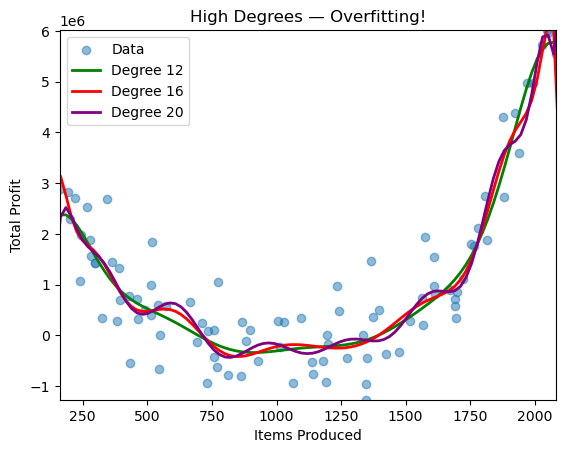

In [24]:
#your code here

colors = ['green', 'red', 'purple']

plt.scatter(X, y, label="Data", alpha=0.5)
X_plot = pd.DataFrame(np.linspace(100, 2200, 100).reshape(-1, 1), columns=['items_produced'])

# zip it an funtion(degrees, colors): loop signifficado:
#for degree, color in zip([12, 16, 20], colors):
#En los grados. colores en zip ([], colores)

for degree, color in zip([12, 16, 20], colors):
    #Pre-Processing
    scaler = StandardScaler()
    poly_features = PolynomialFeatures(degree=degree)
    #fit_trasform vs trasform 
    X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
    X_poly_test = scaler.transform(poly_features.transform(X_test))

    #Training and Prediction
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    
    #Error measurement
    train_error = mean_squared_error(y_train, model.predict(X_poly_train))
    test_error = mean_squared_error(y_test, model.predict(X_poly_test))
    print(f'Degree {degree:2d} — Train MSE: {train_error:,.0f}  |  Test MSE: {test_error:,.0f}')

    y_plot = model.predict(scaler.transform(poly_features.transform(X_plot)))
    plt.plot(X_plot, y_plot, label=f"Degree {degree}", linewidth=2, color=color)

plt.xlim(X['items_produced'].min(), X['items_produced'].max())
plt.ylim(y.min(), y.max())
plt.xlabel('Items Produced')
plt.ylabel('Total Profit')
plt.title('High Degrees — Overfitting!')
plt.legend()
plt.show()

It looks like the more powerufl models are starting to behave in erratic ways, trying to fit too closely to the training data.
They are getting *lower bias*: the data DOES fit better with the training data...
... but the cost of that is *higher variance*: the models becomes swingy and it seems that it's not reflecting real patterns in the data.

# Challenge 4 -Visualizing errors 

Let's see what happens to the errors.
Run the code above in a loop and collect the *train_error* and *test_error* for each degree. Then plot them all.

In [36]:
degrees = [1, 2, 4, 12, 16, 20]
train_errors = []
test_errors = []

for degree in degrees:
    # Step 1: Create polynomial features and scaler for this degree
    # Paso 1: Crear características polinómicas y escalador para este grado
    scaler = StandardScaler()
    poly_features = PolynomialFeatures(degree=degree)

    # Step 2: Transform training and test data
    # Paso 2: Transformar datos de entrenamiento y prueba
    X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
    X_poly_test = scaler.transform(poly_features.transform(X_test))

    # Step 3: Train the model
    # Paso 3: Entrenar el modelo
    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    # Step 4: Calculate errors and append to lists
    # Paso 4: Calcular errores y añadirlos a las listas
    train_error = mean_squared_error(y_train, model.predict(X_poly_train))
    test_error = mean_squared_error(y_test, model.predict(X_poly_test))

    train_errors.append(train_error)   # .append() adds a value to the end of the list
    test_errors.append(test_error)     # .append() añade un valor al final de la lista

    print(f'Degree {degree:2d} → Train MSE: {train_error:>15,.0f}  |  Test MSE: {test_error:>15,.0f}')


Degree  1 → Train MSE: 2,413,863,712,741  |  Test MSE: 2,286,152,701,831
Degree  2 → Train MSE: 508,165,153,636  |  Test MSE: 425,200,367,973
Degree  4 → Train MSE: 382,344,074,348  |  Test MSE: 281,263,489,074
Degree 12 → Train MSE: 361,532,653,313  |  Test MSE: 278,131,719,164
Degree 16 → Train MSE: 344,260,742,058  |  Test MSE: 279,207,313,750
Degree 20 → Train MSE: 334,583,787,470  |  Test MSE: 287,237,171,838


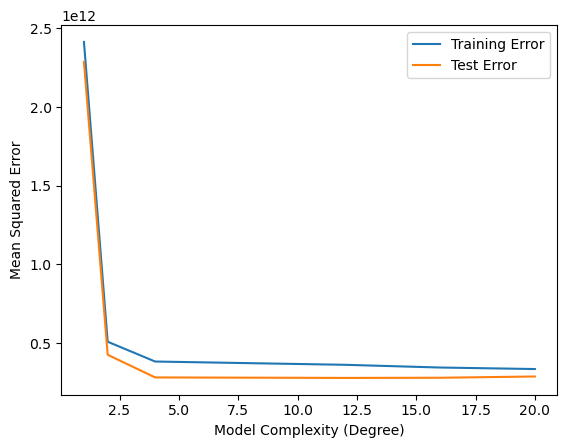

In [38]:
plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, test_errors, label="Test Error")
plt.xlabel("Model Complexity (Degree)")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()


#Ese 'vacío' o distancia entre ambas es el Overfit. Nos indica que el modelo 
#está ganando una confianza falsa 
#basada en datos que ya conoce, pero ha dejado de mejorar para el mundo real."

You see that the training error keeps going down. That is expected: higher order models are more powerful but they start having enough power to fit the noise in the training data. Because of this you see the testing error going up at some point: your model believes natural variation in the training data is part of the fundamental mechanist you are trying to learn and will not be able to generalize. It becomes *overfit*.

# Optional Challenge - Regularization

In [248]:
from sklearn.linear_model import Lasso

#your code here

Regularization is a way of controlling overfitting by imposing a price on the variance of the model. 
Re-run the high dimentionality *degree 20* case above but run a Lasso regression rather than a LinearRegression, with a significant penalty for runaway coefficients.

Hint: where you have 
`model = LinearRegression()`
use instead
`model = Lasso(alpha=100)`

Degree 20 + Lasso — Train MSE: 376,237,339,543  |  Test MSE: 319,243,909,236


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.280e+13, tolerance: 2.199e+10
  model = cd_fast.enet_coordinate_descent(


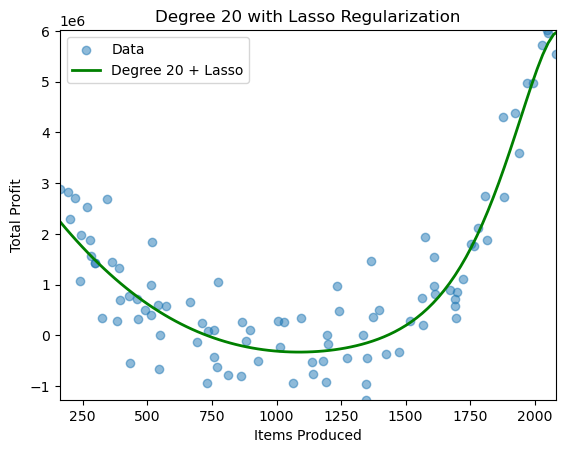

In [43]:
from sklearn.linear_model import Lasso


from sklearn.linear_model import Lasso

scaler = StandardScaler()
poly_features = PolynomialFeatures(degree=20)
X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
X_poly_test = scaler.transform(poly_features.transform(X_test))

# ← KEY CHANGE: Lasso instead of LinearRegression, with alpha=100 penalty
# ← CAMBIO CLAVE: Lasso en vez de LinearRegression, con penalización alpha=100
model = Lasso(alpha=100)
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
y_test_pred = model.predict(X_poly_test)
train_error = mean_squared_error(y_train, y_train_pred)
test_error = mean_squared_error(y_test, y_test_pred)

print(f'Degree 20 + Lasso — Train MSE: {train_error:,.0f}  |  Test MSE: {test_error:,.0f}')

plt.scatter(X, y, label="Data", alpha=0.5)
X_plot = pd.DataFrame(np.linspace(100, 2200, 100).reshape(-1, 1), columns=['items_produced'])
y_plot = model.predict(scaler.transform(poly_features.transform(X_plot)))
plt.plot(X_plot, y_plot, label="Degree 20 + Lasso", linewidth=2, color='green')
plt.xlim(X['items_produced'].min(), X['items_produced'].max())
plt.ylim(y.min(), y.max())
plt.xlabel('Items Produced')
plt.ylabel('Total Profit')
plt.title('Degree 20 with Lasso Regularization')
plt.legend()
plt.show()


And now redo the test_error vs train_error plotting above, but using a Lasso regession rather than a linear regression.

What happens to the bias-variance tradeoff in this case?

Degree  1 (Lasso) → Train MSE: 2,413,863,722,741  |  Test MSE: 2,286,035,307,527
Degree  2 (Lasso) → Train MSE: 508,166,111,947  |  Test MSE: 424,830,202,815
Degree  4 (Lasso) → Train MSE: 416,653,060,341  |  Test MSE: 403,957,019,885
Degree 12 (Lasso) → Train MSE: 394,491,419,070  |  Test MSE: 350,711,627,735
Degree 16 (Lasso) → Train MSE: 386,313,185,051  |  Test MSE: 338,189,763,640
Degree 20 (Lasso) → Train MSE: 376,237,339,543  |  Test MSE: 319,243,909,236


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.108e+13, tolerance: 2.199e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.280e+13, tolerance: 2.199e+10
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.313e+13, toler

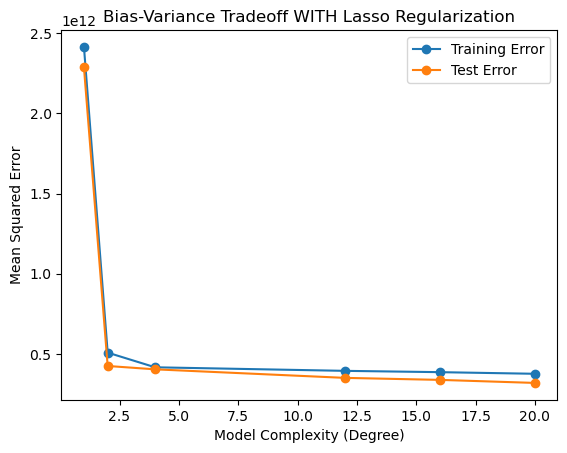

In [46]:
degrees = [1, 2, 4, 12, 16, 20]
train_errors = []
test_errors = []


for degree in degrees:
    scaler = StandardScaler()
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_train = scaler.fit_transform(poly_features.fit_transform(X_train))
    X_poly_test = scaler.transform(poly_features.transform(X_test))

    model = Lasso(alpha=100)   # ← Lasso instead of LinearRegression
    model.fit(X_poly_train, y_train)

    train_error = mean_squared_error(y_train, model.predict(X_poly_train))
    test_error = mean_squared_error(y_test, model.predict(X_poly_test))

    train_errors.append(train_error)
    test_errors.append(test_error)

    print(f'Degree {degree:2d} (Lasso) → Train MSE: {train_error:>15,.0f}  |  Test MSE: {test_error:>15,.0f}')

plt.plot(degrees, train_errors, label="Training Error", marker='o')
plt.plot(degrees, test_errors, label="Test Error", marker='o')
plt.xlabel("Model Complexity (Degree)")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff WITH Lasso Regularization")
plt.legend()
plt.show()

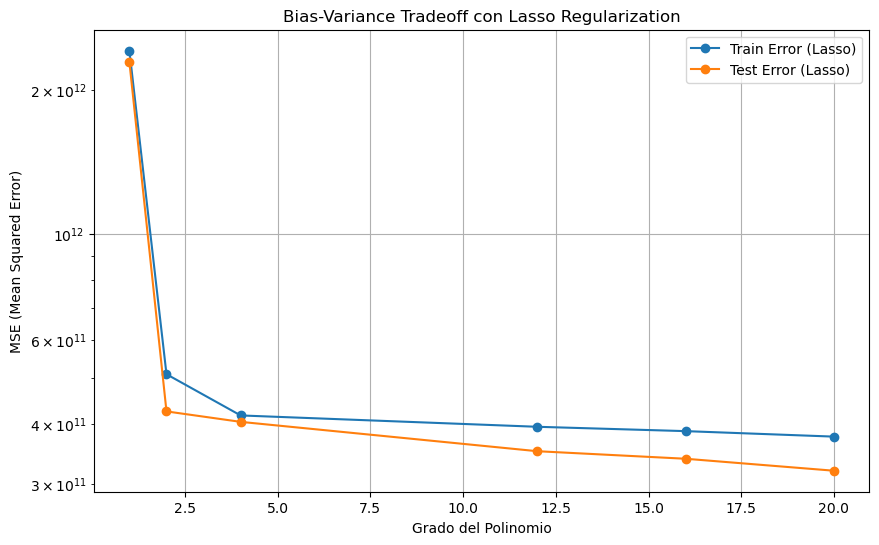

In [44]:


plt.figure(figsize=(10, 6))

# Dibujar las líneas de error
plt.plot(degrees, train_errors, label='Train Error (Lasso)', marker='o')
plt.plot(degrees, test_errors, label='Test Error (Lasso)', marker='o')

# Detalles de la gráfica
plt.title('Bias-Variance Tradeoff con Lasso Regularization')
plt.xlabel('Grado del Polinomio')
plt.ylabel('MSE (Mean Squared Error)')
plt.yscale('log') # Usamos escala logarítmica porque los errores son gigantes
plt.legend()
plt.grid(True)

plt.show()